# NB04 — H1 Test: Biosynthetic Self-Sufficiency

**Hypothesis (from RESEARCH_PLAN.md)**
- **H0**: Clay-isolated genomes show no greater biosynthetic completeness than phylogenetically matched soil baseline.
- **H1**: Clay-isolated genomes have higher mean GapMind amino-acid pathway-complete count than baseline (Beaver & Neufeld 2024 self-sufficiency synthesis; Becraft 2021 *Ca.* Desulforudis audaxviator).

**Method**: Wilcoxon rank-sum on per-genome `aa_pathway_complete` counts; phylum-stratified analysis to control for the Bacillota_B confound surfaced in NB03; Cohen's *d* effect size; sensitivity check excluding low-completeness MAGs (CheckM completeness <80%).

**Caveat from NB02**: anchor_deep includes MAG bins (BRH-c4a, BRH-c8a) with reduced CheckM completeness. We present results both unfiltered and filtered.

In [1]:
from pathlib import Path
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from scipy import stats

DATA_DIR = Path('../data')
FIG_DIR = Path('../figures')
FIG_DIR.mkdir(exist_ok=True)

anchor = pd.read_parquet(DATA_DIR / 'genome_features.parquet')
baseline = pd.read_parquet(DATA_DIR / 'baseline_features.parquet')
all_features = pd.concat([anchor, baseline], ignore_index=True)

# Cast numeric columns
for c in ['checkm_completeness','checkm_contamination','genome_size','gc_percentage']:
    all_features[c] = pd.to_numeric(all_features[c], errors='coerce')

print(f'all features: {len(all_features)} genomes')
print(all_features['cohort_class'].value_counts())
print('\nphylum distribution:')
print(all_features['tax_phylum'].value_counts())

all features: 211 genomes
cohort_class
soil_baseline     150
anchor_shallow     30
unclassified       20
anchor_deep         9
excluded            2
Name: count, dtype: int64

phylum distribution:
tax_phylum
p__Pseudomonadota    81
p__Bacillota         54
p__Bacillota_B       25
p__Actinomycetota    24
p__Bacteroidota      23
p__Spirochaetota      2
p__Deinococcota       1
p__Bacillota_A        1
Name: count, dtype: int64


## 1. Unfiltered comparison: anchor cohorts vs soil baseline

In [2]:
def cohen_d(a, b):
    a, b = np.asarray(a, dtype=float), np.asarray(b, dtype=float)
    pooled_sd = np.sqrt(((a.var(ddof=1)*(len(a)-1)) + (b.var(ddof=1)*(len(b)-1))) / (len(a)+len(b)-2))
    return (a.mean() - b.mean()) / pooled_sd if pooled_sd > 0 else np.nan

def run_test(group_a_label, group_b_label, df, metric='aa_pathway_complete'):
    a = df[df['cohort_class'] == group_a_label][metric].dropna()
    b = df[df['cohort_class'] == group_b_label][metric].dropna()
    if len(a) < 3 or len(b) < 3:
        return None
    u_stat, p = stats.mannwhitneyu(a, b, alternative='two-sided')
    return dict(n_a=len(a), n_b=len(b),
                mean_a=a.mean(), mean_b=b.mean(),
                median_a=a.median(), median_b=b.median(),
                cohens_d=cohen_d(a,b),
                u=u_stat, p=p)

results = []
for grp_a in ['anchor_deep', 'anchor_shallow']:
    for grp_b in ['soil_baseline']:
        r = run_test(grp_a, grp_b, all_features)
        if r:
            r['comparison'] = f'{grp_a} vs {grp_b}'
            r['stratum'] = 'unfiltered'
            results.append(r)
h1_unfiltered = pd.DataFrame(results)
h1_unfiltered

,n_a,n_b,mean_a,mean_b,median_a,median_b,cohens_d,u,p,comparison,stratum
0,9,150,16.222222,16.66,17.0,18.0,-0.172668,507.0,0.152711,anchor_deep vs soil_baseline,unfiltered
1,30,150,17.866667,16.66,18.0,18.0,0.522559,2843.0,0.006314,anchor_shallow vs soil_baseline,unfiltered


## 2. CheckM-filtered (≥80% completeness, ≤5% contamination) comparison

Excludes MAGs with low completeness which would systematically suppress GapMind pathway counts regardless of biology.

In [3]:
qc = all_features[(all_features['checkm_completeness'] >= 80) & (all_features['checkm_contamination'] <= 5)].copy()
print(f'after QC filter: {len(qc)} of {len(all_features)} genomes retained')
print(qc['cohort_class'].value_counts())

results_qc = []
for grp_a in ['anchor_deep', 'anchor_shallow']:
    r = run_test(grp_a, 'soil_baseline', qc)
    if r:
        r['comparison'] = f'{grp_a} vs soil_baseline'
        r['stratum'] = 'checkm>=80'
        results_qc.append(r)
h1_qc = pd.DataFrame(results_qc)
h1_qc

after QC filter: 191 of 211 genomes retained
cohort_class
soil_baseline     137
anchor_shallow     30
unclassified       16
anchor_deep         6
excluded            2
Name: count, dtype: int64


,n_a,n_b,mean_a,mean_b,median_a,median_b,cohens_d,u,p,comparison,stratum
0,6,137,15.500000,17.138686,16.5,18.0,-0.842150,194.5,0.009461,anchor_deep vs soil_baseline,checkm>=80
1,30,137,17.866667,17.138686,18.0,18.0,0.425123,2470.0,0.028907,anchor_shallow vs soil_baseline,checkm>=80


## 3. Per-phylum within-stratum tests (controls phylogenetic confound)

In [4]:
phylum_results = []
for phylum in qc['tax_phylum'].dropna().unique():
    sub = qc[qc['tax_phylum'] == phylum]
    for grp_a in ['anchor_deep', 'anchor_shallow']:
        r = run_test(grp_a, 'soil_baseline', sub)
        if r:
            r['phylum'] = phylum
            r['comparison'] = f'{grp_a} vs soil_baseline'
            phylum_results.append(r)
h1_phylum = pd.DataFrame(phylum_results)
h1_phylum

,n_a,n_b,mean_a,mean_b,median_a,median_b,cohens_d,u,p,phylum,comparison
0,16,45,18.00,17.488889,18.0,18.0,0.425215,424.0,0.075892,p__Pseudomonadota,anchor_shallow vs soil_baseline
1,10,40,17.70,17.675000,18.0,18.0,0.044909,198.0,0.962942,p__Bacillota,anchor_shallow vs soil_baseline
2,4,17,17.75,17.235294,18.0,18.0,0.385852,37.5,0.735996,p__Actinomycetota,anchor_shallow vs soil_baseline
3,4,19,16.50,16.789474,16.5,18.0,-0.129979,17.0,0.073495,p__Bacillota_B,anchor_deep vs soil_baseline


## 4. Visualization

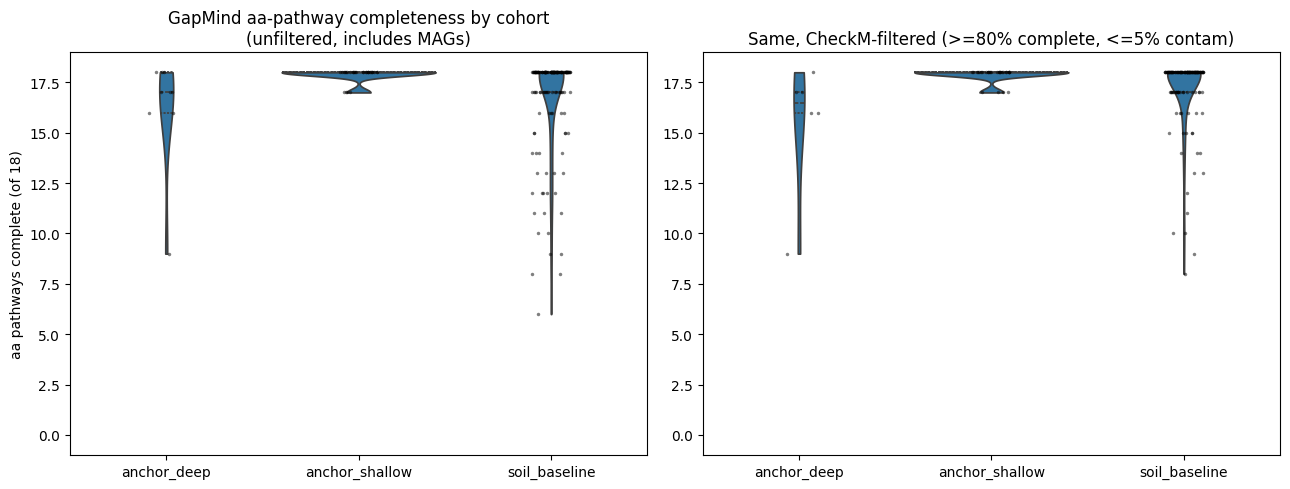

saved: ../figures/h1_self_sufficiency_violin.png


In [5]:
fig, axes = plt.subplots(1, 2, figsize=(13, 5))

# Left: unfiltered
order = ['anchor_deep', 'anchor_shallow', 'soil_baseline']
data = all_features[all_features['cohort_class'].isin(order)]
sns.violinplot(data=data, x='cohort_class', y='aa_pathway_complete', order=order, ax=axes[0], inner='quartile', cut=0)
sns.stripplot(data=data, x='cohort_class', y='aa_pathway_complete', order=order, ax=axes[0], color='black', size=2.5, alpha=0.5)
axes[0].set_title('GapMind aa-pathway completeness by cohort\n(unfiltered, includes MAGs)')
axes[0].set_xlabel('')
axes[0].set_ylabel('aa pathways complete (of 18)')
axes[0].set_ylim(-1, 19)

# Right: QC-filtered
data_qc = qc[qc['cohort_class'].isin(order)]
sns.violinplot(data=data_qc, x='cohort_class', y='aa_pathway_complete', order=order, ax=axes[1], inner='quartile', cut=0)
sns.stripplot(data=data_qc, x='cohort_class', y='aa_pathway_complete', order=order, ax=axes[1], color='black', size=2.5, alpha=0.5)
axes[1].set_title('Same, CheckM-filtered (>=80% complete, <=5% contam)')
axes[1].set_xlabel('')
axes[1].set_ylabel('')
axes[1].set_ylim(-1, 19)

plt.tight_layout()
out_fig = FIG_DIR / 'h1_self_sufficiency_violin.png'
plt.savefig(out_fig, dpi=140, bbox_inches='tight')
plt.show()
print(f'saved: {out_fig}')

## 5. Save results table

In [6]:
all_results = pd.concat([h1_unfiltered, h1_qc, h1_phylum], ignore_index=True)
out_path = DATA_DIR / 'h1_self_sufficiency.tsv'
all_results.to_csv(out_path, sep='\t', index=False)
print(f'saved: {out_path}')
all_results.round(3)

saved: ../data/h1_self_sufficiency.tsv


,n_a,n_b,mean_a,mean_b,median_a,median_b,cohens_d,u,p,comparison,stratum,phylum
0,9,150,16.222,16.660,17.0,18.0,-0.173,507.0,0.153,anchor_deep vs soil_baseline,unfiltered,NaN
1,30,150,17.867,16.660,18.0,18.0,0.523,2843.0,0.006,anchor_shallow vs soil_baseline,unfiltered,NaN
2,6,137,15.500,17.139,16.5,18.0,-0.842,194.5,0.009,anchor_deep vs soil_baseline,checkm>=80,NaN
3,30,137,17.867,17.139,18.0,18.0,0.425,2470.0,0.029,anchor_shallow vs soil_baseline,checkm>=80,NaN
4,16,45,18.000,17.489,18.0,18.0,0.425,424.0,0.076,anchor_shallow vs soil_baseline,NaN,p__Pseudomonadota
5,10,40,17.700,17.675,18.0,18.0,0.045,198.0,0.963,anchor_shallow vs soil_baseline,NaN,p__Bacillota
6,4,17,17.750,17.235,18.0,18.0,0.386,37.5,0.736,anchor_shallow vs soil_baseline,NaN,p__Actinomycetota
7,4,19,16.500,16.789,16.5,18.0,-0.130,17.0,0.073,anchor_deep vs soil_baseline,NaN,p__Bacillota_B
